### 4.1.2 Recorte e visualização customizada das séries temporais de cada estação

<div style="text-align: justify">Esta subseção fornece um mapa interativo para a visualização das séries temporais das concentrações de poluentes atmosféricos no Brasil. Essa ferramenta possibilita a seleção da estação conforme a sua localização, bem como a seleção do poluente e do período de interesse. A ferramenta também possibilita que o usuário faça o <i>download</i> dos dados em arquivos .csv. </div>

```{tip}
A Figura 33 possibilita a seleção de cada estação de monitoramento, poluente e período de interesse para a visualização da série temporal e estatísticas descritivas.

```
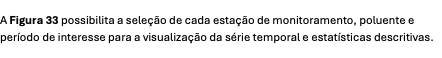
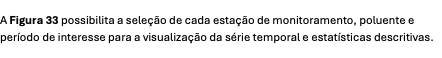
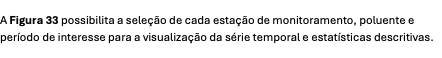
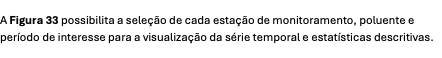

<!-- Estilo -->
<style>
    
/* Reestilizando botões */
.appBtn {
  appearance: none;
  background-color: #FAFBFC;
  border: 1px solid rgba(27, 31, 35, 0.15);
  border-radius: 6px;
  box-shadow: rgba(27, 31, 35, 0.04) 0 1px 0, rgba(255, 255, 255, 0.25) 0 1px 0 inset;
  box-sizing: border-box;
  color: #24292E;
  cursor: pointer;
  display: inline-block;
  font-family: -apple-system, system-ui, "Segoe UI", Helvetica, Arial, sans-serif, "Apple Color Emoji", "Segoe UI Emoji";
  font-size: 14px;
  font-weight: 500;
  line-height: 20px;
  padding: 6px 16px;
  transition: background-color 0.2s;
  vertical-align: middle;
  background: unset;
}
.appBtn:hover { background-color: #F3F4F6; }
.appBtn:disabled { color: #959DA5; cursor: default; }

/* Tabela de estatísticas */
.stats-table {
  border-collapse: collapse;
  width: 100%;
  margin: 15px auto; /* centraliza horizontalmente */
  max-width: 500px;
  margin-top: 20px;
  font-family: Arial, sans-serif;
  background-color: #FAFBFC;
  border: 1px solid rgba(27,31,35,0.15);
  border-radius: 8px;
  overflow: hidden;
}
.stats-table th, .stats-table td {
  padding: 8px 12px;
  text-align: left;
}
.stats-table th {
  background-color: #F3F4F6;
  font-weight: 600;
}
.stats-table tr:nth-child(even) {
  background-color: #F9F9F9;
}
    
</style>

<script src="https://cdn.plot.ly/plotly-2.26.1.min.js"></script>
<script src="https://cdn.jsdelivr.net/npm/papaparse@5.4.1/papaparse.min.js"></script>

<div id="mapDiv" style="width:100%; height:400px; margin-top:15px;"></div>
<br>   
<div>
  <label>Estação:</label>
  <select id="stationSelect"></select> <!-- agora é só display -->

  <label>Poluente:</label>
  <select id="pollutantSelect"></select>
  <br><br>
  <label>Início:</label>
  <input type="datetime-local" id="startDate">

  <label>Final:</label>
  <input type="datetime-local" id="endDate">
  <br><br>
  <button id="loadDataBtn" class="btn appBtn">Carrega dados</button>
  <button id="plotBtn" class="btn appBtn" disabled>Plot</button>
  <button id="downloadBtn" class="btn appBtn" disabled>Download CSV</button>
</div>

<div id="plotDiv" style="width:100%; height:600px;"></div>
<div id="statsDiv"></div> <!-- tabela de estatísticas -->

<script>
const DATA_FOLDER = 'https://arquivos.lcqar.ufsc.br/data/databases/stations/MQAr';
const METADATA_CSV = 'https://arquivos.lcqar.ufsc.br/data/databases/stations/Monitoramento_QAr_BR.csv';

let metadata = [], stationPollutants = {}, currentData = [], filteredData = [];
let mapDivEl, stationIds = [];
let stationCoordsArr = []

// Carrega metadados
Papa.parse(METADATA_CSV, {
  download: true,
  header: true,
  complete: function(results) {
    const stationMap = {};
    metadata = results.data.filter(r => r.ID_MMA && r.POLUENTE);
    metadata.forEach(r=>{
      const id = (r.ID_MMA||'').toString().trim();
      const lat = parseFloat((r.LATITUDE||'').toString().replace(',','.'));
      const lon = parseFloat((r.LONGITUDE||'').toString().replace(',','.'));
      if(!id || Number.isNaN(lat) || Number.isNaN(lon)) return;
      if(!stationMap[id]) stationMap[id] = r; // mantém a primeira ocorrência
    });
    stationCoordsArr = Object.values(stationMap);

    populateStationsDropdown();
    buildStationPollutantsMap();
    populatePollutantSelect();   // poluentes gerais
    plotStationsMap();           // mapa
  }
});

// ---------- FUNÇÕES ----------
function buildStationPollutantsMap() {
  stationPollutants = {};
  metadata.forEach(row => {
    if(!stationPollutants[row.ID_MMA]) stationPollutants[row.ID_MMA] = new Set();
    stationPollutants[row.ID_MMA].add(row.POLUENTE);
  });
  for(const st in stationPollutants) stationPollutants[st] = Array.from(stationPollutants[st]).sort();
}

function populatePollutantSelect() {
  const sel = document.getElementById('pollutantSelect');
  sel.innerHTML = '';
  Array.from(new Set(metadata.map(r => r.POLUENTE))).sort().forEach(pol=>{
    const opt = document.createElement('option'); opt.value=pol; opt.textContent=pol;
    sel.appendChild(opt);
  });
}

function populateStationsDropdown() {
  const stationSel = document.getElementById('stationSelect');
  stationCoordsArr.forEach(
    (r) => {
      const option = document.createElement('option');
      option.value = r.ID_MMA;
      option.textContent = `${r.ID_MMA} - ${r.ID_OEMA}`;

      stationSel.appendChild(option);
    });
}

function plotStationsMap() {
  if (!stationCoordsArr.length) return;
  const lats = stationCoordsArr.map(r => parseFloat(r.LATITUDE)).filter(v=>!isNaN(v));
  const lons = stationCoordsArr.map(r => parseFloat(r.LONGITUDE)).filter(v=>!isNaN(v));
  const texts = stationCoordsArr.map(r => `${r.ID_MMA} - ${r.ID_OEMA}`);
  stationIds = stationCoordsArr.map(r=>r.ID_MMA);
  const colors = stationCoordsArr.map(r => r.BASE_DADOS === 'True' ? 'blue' : '#808080'
  );
//   const colors = Array(stationIds.length).fill('blue');

  const trace = {
    type: "scattermapbox",
    lat: lats,
    lon: lons,
    mode: "markers",
    text: texts,
    customdata: stationIds,
    marker: { 
      size: 10, 
      color: colors,
      opacity: Array(stationIds.length).fill(0.8)
    },
    hoverinfo: "text",
    showlegend: false
  };

  // Adicionando traces fantasmas, só para ter legenda
    const legendBlue = {
    type: "scattermapbox",
    mode: "markers",
    lat: [null], lon: [null],
    marker: { size: 10, color: 'blue' },
    name: "Com base de dados",
    showlegend: true,
    hoverinfo: "none"
  };

  const legendGray = {
    type: "scattermapbox",
    mode: "markers",
    lat: [null], lon: [null],
    marker: { size: 10, color: '#808080' },
    name: "Sem base de dados",
    showlegend: true,
    hoverinfo: "none"
  };

  const layout = {
    mapbox: { style:'open-street-map', center:{lat:lats[0],lon:lons[0]}, zoom:2 },
    margin:{t:0,b:0,l:0,r:0},
    legend: {
        title: { text: 'Situação das Estações' },
        x: 0.99,             // lado direito
        xanchor: 'right', // ancora à direita
        y: 0.12,             // parte de baixo
        yanchor: 'bottom',// ancora na base
        bgcolor: 'rgba(255,255,255,0.7)', // fundo semitransparente (para ver o mapa)
        bordercolor: 'rgba(0,0,0,0.3)',
        borderwidth: 1,
        font: { size: 12 }
    }
  };

  mapDivEl = document.getElementById('mapDiv');
  Plotly.newPlot(mapDivEl, [trace, legendBlue, legendGray], layout, showlegend=true);

  mapDivEl.on('plotly_click', function(data){
    if(data.points.length>0) selectStation(data.points[0].customdata);
  });
}

// Seleciona estação no clique do mapa
function selectStation(stationId){
  // Atualiza visual no mapa
  const newColors = stationCoordsArr.map(r => r.ID_MMA === stationId ? 'lime' : (r.BASE_DADOS === 'True' ? 'blue' : '#808080'));
  const newSizes  = stationIds.map(id => id === stationId ? 18 : 10);
  const newAlpha  = stationIds.map(id => id === stationId ? 1 : 0.8);

  Plotly.restyle(mapDivEl, {
    'marker.color': [newColors], 
    'marker.size': [newSizes],
    'marker.opacity': [newAlpha]
  }, [0]);

  // Centraliza mapa na estação
  const idx = stationIds.indexOf(stationId);
  Plotly.relayout(mapDivEl, {
    'mapbox.center.lat': parseFloat(stationCoordsArr[idx].LATITUDE),
    'mapbox.center.lon': parseFloat(stationCoordsArr[idx].LONGITUDE),
    'mapbox.zoom': 10
  });

  // Atualiza dropdown de estação (somente display)
  const stationSel = document.getElementById('stationSelect');
  stationSel.value = stationId
  //stationSel.innerHTML = '';
  //const opt = document.createElement('option');
  //opt.value = stationId;
  //opt.textContent = stationId;
  //stationSel.appendChild(opt);

  // Desabilita botão "Carrega dados" para dados inexistentes
  const haveData = metadata.some(r =>
    r.ID_MMA === stationId && String(r.BASE_DADOS).toLowerCase() === 'true'
  );

  const loadButton = document.getElementById('loadDataBtn')
  if(!haveData){
    loadButton.textContent = 'Sem dados para carregar'
    loadButton.disabled = true
  } else {
    loadButton.textContent = 'Carregar dados'
    loadButton.disabled = false
  }

  // encontra metadado da estação selecionada
  // const meta = stationCoordsArr.find(m => m.ID_MMA === stationId);

  // atualiza dropdown
  // const stationSel = document.getElementById('stationSelect');
  // stationSel.innerHTML = '';

  // const opt = document.createElement('option');
  // opt.value = stationId;
  // opt.textContent = `${stationId} - ${meta ? meta.ID_OEMA : ''}`;
  // stationSel.appendChild(opt);
    
  // Atualiza poluentes disponíveis da estação
  const polSel = document.getElementById('pollutantSelect');
  polSel.innerHTML = '';
  (stationPollutants[stationId] || []).forEach(pol=>{
    const optPol = document.createElement('option');
    optPol.value = pol;
    optPol.textContent = pol;
    polSel.appendChild(optPol);
  });
}

// ---------- CARREGAMENTO E PLOT ----------
document.getElementById('loadDataBtn').addEventListener('click', ()=>{
  const pol = document.getElementById('pollutantSelect').value;
  const st = document.getElementById('stationSelect').value;
  if(!pol||!st){ alert('Clique em uma estação no mapa e selecione um poluente.'); return; }
  const row=metadata.find(r=>r.ID_MMA===st && r.POLUENTE===pol);
  if(!row){ alert("Combinação estação+poluente não encontrada."); return; }
  const fileUrl = `${DATA_FOLDER}/${pol}/${row.ID_MMA_COMPLETO}.csv`;
  Papa.parse(fileUrl,{download:true,header:true,
    complete:function(res){ currentData=res.data;
      alert(`Dados carregados: ${currentData.length} linhas.`);
      document.getElementById('plotBtn').disabled=false;
      document.getElementById('downloadBtn').disabled=true;
      setDateLimits(currentData);
    },
    error:function(err){ alert(`Erro ao carregar arquivo: ${fileUrl}\n${err}`); }
  });
});

function setDateLimits(data){
  let dates = data.map(r=>r.ANO && r.MES && r.DIA && r.HORA ? new Date(r.ANO,r.MES-1,r.DIA,r.HORA) : null)
                  .filter(d=>d instanceof Date && !isNaN(d));
  if(!dates.length) return;
  const min=new Date(Math.min(...dates)), max=new Date(Math.max(...dates));
  const pad=n=>n.toString().padStart(2,'0');
  document.getElementById('startDate').value = `${min.getFullYear()}-${pad(min.getMonth()+1)}-${pad(min.getDate())}T${pad(min.getHours())}:${pad(min.getMinutes())}`;
  document.getElementById('endDate').value = `${max.getFullYear()}-${pad(max.getMonth()+1)}-${pad(max.getDate())}T${pad(max.getHours())}:${pad(max.getMinutes())}`;
}

document.getElementById('plotBtn').addEventListener('click', ()=>{
  if(!currentData.length){ alert('Nenhum dado carregado.'); return; }
  const start=new Date(document.getElementById('startDate').value);
  const end=new Date(document.getElementById('endDate').value);

  filteredData=currentData.map(r=>{
    let dt=new Date(r.ANO,r.MES-1,r.DIA,r.HORA);
    let val=parseFloat((r.VALOR||'').replace(',','.'));
    if(val<0||isNaN(val)) val=null;
    return {datetime:dt, valor:val};
  }).filter(r=>r.datetime>=start && r.datetime<=end);

  filteredData.sort((a,b)=>a.datetime-b.datetime);
  let segments=[], curX=[], curY=[];
  filteredData.forEach(p=>{
    if(p.valor==null||isNaN(p.valor)){ if(curX.length){ segments.push({x:curX,y:curY}); curX=[];curY=[];} }
    else { curX.push(p.datetime); curY.push(p.valor); }
  });
  if(curX.length) segments.push({x:curX,y:curY});
  const traces=segments.map(s=>({x:s.x,y:s.y,mode:'lines',line:{color:'blue',width:1},showlegend:false}));
  Plotly.react('plotDiv', traces, {
    title:`Série temporal - ${document.getElementById('stationSelect').value} - ${document.getElementById('pollutantSelect').value}`,
    hovermode:'x unified',
    plot_bgcolor:'rgba(.6,.6,.6,0.3)',
    yaxis:{title:'Concentração', rangemode:'nonnegative'},
    xaxis:{title:'Data/Hora'}
  });

  document.getElementById('downloadBtn').disabled = filteredData.length===0;

  updateStatsTable(); // Atualiza tabela de estatísticas
});

document.getElementById('downloadBtn').addEventListener('click', ()=>{
  if(!filteredData.length){ alert('Nenhum dado filtrado.'); return; }
  const csvData = filteredData.map(r=>({DataHora:r.datetime.toISOString(), Valor:r.valor}));
  const csvString = Papa.unparse(csvData);
  const blob = new Blob([csvString], {type:'text/csv;charset=utf-8;'});
  const url = URL.createObjectURL(blob);
  const station=document.getElementById('stationSelect').value;
  const pollutant=document.getElementById('pollutantSelect').value;
  const filename=`${station}_${pollutant}_filtrado.csv`;
  const link=document.createElement('a'); link.href=url; link.download=filename; document.body.appendChild(link); link.click(); document.body.removeChild(link);
});

function updateStatsTable() {
  if(!filteredData.length) {
    document.getElementById('statsDiv').innerHTML = '';
    return;
  }

  const values = filteredData.map(d=>d.valor).filter(v=>v!=null && !isNaN(v));
  const total = filteredData.length;
  const nulos = total - values.length;
  const percNaoNulos = ((values.length/total)*100).toFixed(2) + '%';

  if(values.length===0){
    document.getElementById('statsDiv').innerHTML = '<p>Nenhum valor válido para estatísticas.</p>';
    return;
  }

  values.sort((a,b)=>a-b);

  const percentile = (arr,p) => {
    const idx = (arr.length-1)*(p/100);
    const lower = Math.floor(idx), upper = Math.ceil(idx);
    if(lower===upper) return arr[lower];
    return arr[lower] + (arr[upper]-arr[lower])*(idx-lower);
  };

  const stats = {
    'Média': (values.reduce((a,b)=>a+b,0)/values.length).toFixed(2),
    'Mínimo': values[0].toFixed(2),
    'Máximo': values[values.length-1].toFixed(2),
    '90º Percentil': percentile(values,90).toFixed(2),
    '95º Percentil': percentile(values,95).toFixed(2),
    '99º Percentil': percentile(values,99).toFixed(2),
    'Valores válidos': values.length,
    'Valores nulos': nulos,
    '% Não nulos': percNaoNulos
  };
  
  let html = '<table class="stats-table">';
  html += '<tr><th>Estatística</th><th>Valor</th></tr>';
  for(const key in stats){
    html += `<tr><td>${key}</td><td>${stats[key]}</td></tr>`;
  }
  html += '</table>';

  document.getElementById('statsDiv').innerHTML = html;
}


/** EVENTS **/
document.addEventListener('DOMContentLoaded', function() {
  const stationSel = document.getElementById('stationSelect');
  stationSel.addEventListener('change', function() {
    const selectedOption = stationSel.options[stationSel.selectedIndex];
    console.log(selectedOption.value);
    selectStation(selectedOption.value);
  });
  
});


</script>

</body>
</html>


<p style="text-align:center; color:#636D7D; font-size:15.5px;">
  <em>Fig. 33</em> Ferramenta de seleção, recorte e análise dos dados de monitoramento da qualidade do ar no Brasil.
</p>
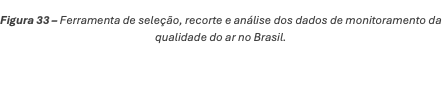
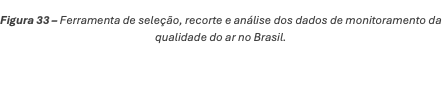
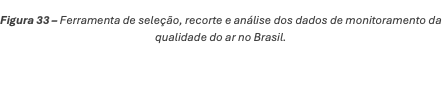
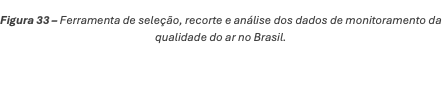